In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

df_100 = pd.read_csv(r"C:\Users\Fiasco\Desktop\AAV_Capsid_Design\src\evaluation\plots\tm_pdb\sample_random_500.csv")

In [2]:
WT = ("MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLVLPGYKYLGPFNGLDKGEPVNEADAAALEHDKAYDRQLDSGDNPYLKYNHADAEFQERLKEDTSFGGNLGRAVFQAKKRVLEPLGLVEEPVKTAPGKKRPVEHSPVEPDSSSGTGKAGQQPARKRLNFGQTGDADSVPDPQPLGQPPAAPSGLGTNTMATGSGAPMADNNEGADGVGNSSGNWHCDSTWMGDRVITTSTRTWALPTYNNHLYKQISSQSGASNDNHYFGYSTPWGYFDFNRFHCHFSPRDWQRLINNNWGFRPKRLNFKLFNIQVKEVTQNDGTTTIANNLTSTVQVFTDSEYQLPYVLGSAHQGCLPPFPADVFMVPQYGYLTLNNGSQAVGRSSFYCLEYFPSQMLRTGNNFTFSYTFEDVPFHSSYAHSQSLDRLMNPLIDQYLYYLSRTNTPSGTTTQSRLQFSQAGASDIRDQSRNWLPGPCYRQQRVSKTSADNNNSEYSWTGATKYHLNGRDSLVNPGPAMASHKDDEEKFFPQSGVLIFGKQGSEKTNVDIEKVMITDEEEIRTTNPVATEQYGSVSTNLQRGNRQAATADVNTQGVLPGMVWQDRDVYLQGPIWAKIPHTDGHFHPSPLMGGFGLKHPPPQILIKNTPVPANPSTTFSAAKFASFITQYSTGQVSVEIEWELQKENSKRWNPEIQYTSNYNKSVNVDFTVDTNGVYSEPRPIGTRYLTRNL")
def get_vp3(seq): 
    return seq[216 :]
WT = get_vp3(WT)

AA_ALPHABET = list("ACDEFGHIKLMNPQRSTVWY")

dist = [len(i)- len(WT) for i in df_100["generate_seqs"]]

start = 342
end = 519

In [3]:
import random

def generate_sequences_with_insertions(
    wt_seq, dist, aa_alphabet, start=342, end=519, n=200, seed=42
):
    """
    Generate n sequences by randomly inserting amino acids into wt_seq
    within [start, end], where the number of insertions per sequence
    is sampled from dist (only positive values = insertions).

    Args:
        wt_seq     : WT amino acid sequence (post get_vp3)
        dist       : list of length differences (e.g. len(gen) - len(WT))
        aa_alphabet: list of amino acid characters to insert
        start      : insertion region start index (inclusive)
        end        : insertion region end index (inclusive)
        n          : number of sequences to generate
        seed       : random seed for reproducibility

    Returns:
        List of n generated sequences (strings)
    """
    random.seed(seed)

    # Only keep positive values — these represent insertions
    insert_dist = [d for d in dist if d > 0]

    if not insert_dist:
        raise ValueError("dist contains no positive values — no insertions to sample from.")

    generated_seqs = []

    for _ in range(n):
        # Sample the number of AAs to insert from the empirical distribution
        n_insert = random.choice(insert_dist)

        seq = list(wt_seq)

        # Pick n_insert positions within [start, end], sorted descending
        # to avoid index-shifting when inserting left-to-right
        positions = sorted(
            [random.randint(start, min(end, len(seq) - 1)) for _ in range(n_insert)],
            reverse=True
        )

        for pos in positions:
            aa = random.choice(aa_alphabet)
            seq.insert(pos, aa)

        generated_seqs.append("".join(seq))

    return generated_seqs


# ── Run ──────────────────────────────────────────────────────────────────────
new_sequences = generate_sequences_with_insertions(
    wt_seq     = WT,
    dist       = dist,
    aa_alphabet= AA_ALPHABET,
    start      = start,
    end        = end,
    n          = 250,
)

# Quick sanity check
print(f"Generated : {len(new_sequences)} sequences")
print(f"WT length : {len(WT)}")
print(f"Length range of generated seqs: {min(len(s) for s in new_sequences)} – {max(len(s) for s in new_sequences)}")
print(f"\nExample (first seq, positions {start-5}:{end+5}):")
print(new_sequences[6][start-5 : end+10])

Generated : 250 sequences
WT length : 519
Length range of generated seqs: 520 – 999

Example (first seq, positions 337:524):
IEKVMITDEEEIRTTNPVATEQYKGSVSTNLQRGNRQAATADVNTQGVLPGMVWQDRDVPYLQGPIWAKIPHTDGRHFHPSPLMGGFGLKHPPPQILIKNTPVPANPSTTFSAAKFASFITQYSTGQVSVEIEWELQKENSKRWNPEIQYTSNYNKSVNVDFTGVDTNGVYSEPIRPIGTRVYLTGRNL


In [ ]:
[len(i) for i in   new_sequences]

In [9]:
import json
import os

# Get the sequences

# Create a directory for the JSON files (optional)
output_dir = r"C:\Users\Fiasco\Desktop\AAV_Capsid_Design\src\evaluation\plots\tm_pdb\250_random_jsons"
os.makedirs(output_dir, exist_ok=True)

# Generate a JSON file for each sequence
for idx, sequence in enumerate(new_sequences, start=1):
    # Create the JSON structure
    json_data = [
        {
            "name": f"random_{idx}_100",
            "modelSeeds": [],
            "sequences": [
                {
                    "proteinChain": {
                        "sequence": sequence,
                        "count": 1
                    }
                }
            ],
            "dialect": "alphafoldserver",
            "version": 1
        }
    ]
    
    # Create filename
    filename = f"random_{idx}_100.json"
    filepath = os.path.join(output_dir, filename)
    
    # Write to JSON file
    with open(filepath, 'w') as f:
        json.dump(json_data, f, indent=2)

print(f"Successfully created {len(new_sequences)} JSON files in '{output_dir}' directory")

Successfully created 250 JSON files in 'C:\Users\Fiasco\Desktop\AAV_Capsid_Design\src\evaluation\plots\tm_pdb\250_random_jsons' directory


In [21]:
import pandas as pd 

df_random = pd.DataFrame({"generate_seqs":new_sequences})

In [22]:
df_random.to_csv("random_250_generated.csv" , index = False)

In [25]:
df_scores = pd.read_csv(r"C:\Users\Fiasco\Desktop\AAV_Capsid_Design\src\evaluation\plots\final_random_250_generated_evalluated.csv")

In [12]:
df_folded = pd.read_csv(r"C:\Users\Fiasco\Desktop\AAV_Capsid_Design\docs\large_files\fold_100\clean_random\rmsd_results_simple.csv")

In [14]:
df_folded["median_rmsd"] = df_folded[["rmsd_model_0", "rmsd_model_1", "rmsd_model_2", "rmsd_model_3", "rmsd_model_4"]].median(axis=1)

In [29]:
df_final = df_scores[:  59].join(df_folded)


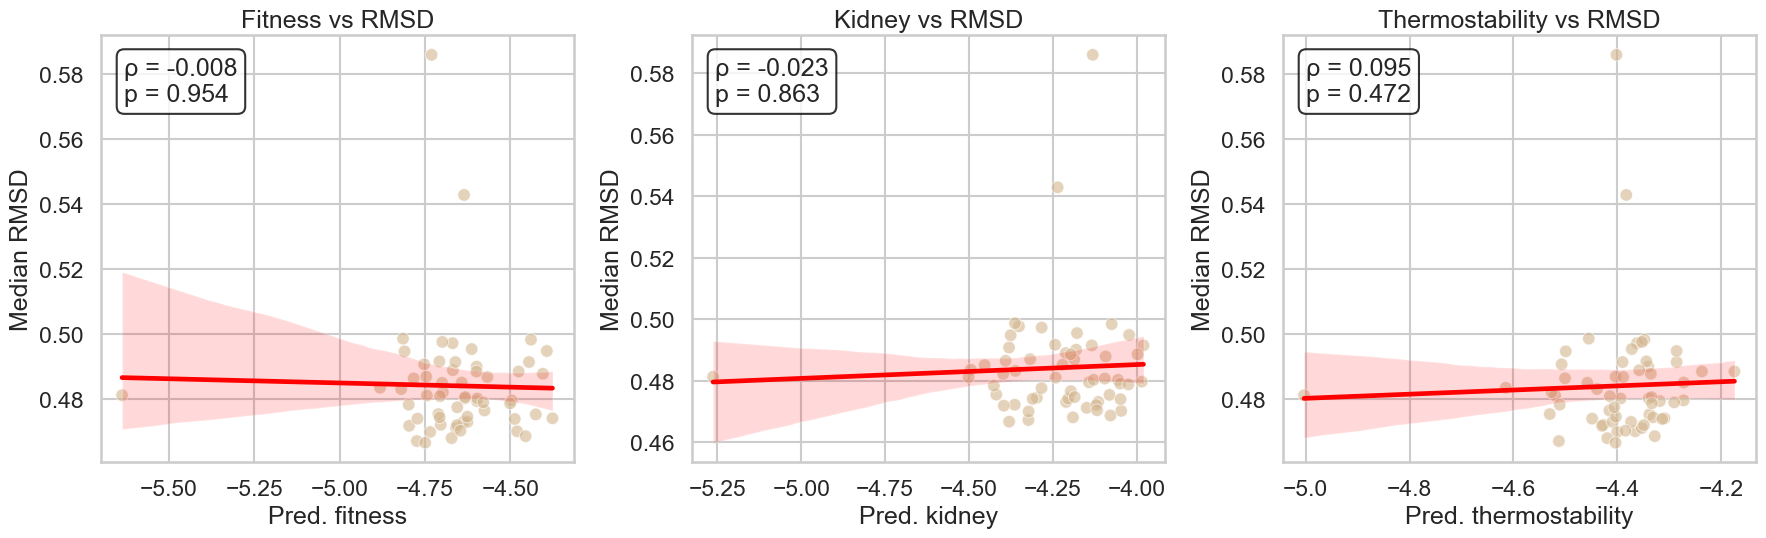

CORRELATION SUMMARY WITH MEDIAN RMSD:
Pred. thermostability    : ρ = +0.095    (p = 4.724e-01)
Pred. kidney             : ρ = -0.023    (p = 8.629e-01)
Combined score           : ρ = -0.014    (p = 9.150e-01)
Pred. fitness            : ρ = -0.008    (p = 9.541e-01)


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'Arial' 

map = {
    "pred_fitness": "Pred. fitness", 
    "pred_kidney": "Pred. kidney",
    "pred_them": "Pred. thermostability",
    "median_rmsd": "Median RMSD",
    "composite_score": "Combined score"
}

def analyze_top_performers_seaborn(df):
    """Find and visualize correlations with RMSD using seaborn styling"""
    
    # Copy dataframe
    df_analysis = df.copy()
    
    # Ensure composite_score exists
    if 'composite_score' not in df_analysis.columns:
        df_analysis['composite_score'] = (
            df_analysis['pred_fitness'] + 
            df_analysis['pred_kidney'] + 
            df_analysis['pred_them']
        ) / 3
    
    # Create performance categories
    df_analysis['category'] = 'Regular'
    
    # Define custom colors
    colors = {'Regular': '#D2B48C'}
    
    # Set up figure for 4 subplots
    fig = plt.figure(figsize=(18, 6))
    
    # Plot 1: pred_fitness vs median_rmsd
    ax1 = fig.add_subplot(131)
    sns.scatterplot(
        data=df_analysis, x='pred_fitness', y='median_rmsd', 
        hue='category', palette=colors, alpha=0.6, ax=ax1, legend=False
    )
    sns.regplot(
        data=df_analysis, x='pred_fitness', y='median_rmsd',
        scatter=False, color='red', ax=ax1
    )
    spearman_corr, p_value = spearmanr(df_analysis['pred_fitness'], df_analysis['median_rmsd'])
    ax1.text(0.05, 0.95, f'ρ = {spearman_corr:.3f}\np = {p_value:.3f}',
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, 
                      edgecolor='black', linewidth=1.5))
    ax1.set_xlabel(map['pred_fitness'])
    ax1.set_ylabel(map['median_rmsd'])
    ax1.set_title('Fitness vs RMSD')
    
    # Plot 2: pred_kidney vs median_rmsd
    ax2 = fig.add_subplot(132)
    sns.scatterplot(
        data=df_analysis, x='pred_kidney', y='median_rmsd', 
        hue='category', palette=colors, alpha=0.6, ax=ax2, legend=False
    )
    sns.regplot(
        data=df_analysis, x='pred_kidney', y='median_rmsd',
        scatter=False, color='red', ax=ax2
    )
    spearman_corr, p_value = spearmanr(df_analysis['pred_kidney'], df_analysis['median_rmsd'])
    ax2.text(0.05, 0.95, f'ρ = {spearman_corr:.3f}\np = {p_value:.3f}',
             transform=ax2.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8,
                      edgecolor='black', linewidth=1.5))
    ax2.set_xlabel(map['pred_kidney'])
    ax2.set_ylabel(map['median_rmsd'])
    ax2.set_title('Kidney vs RMSD')
    
    # Plot 3: pred_them vs median_rmsd
    ax3 = fig.add_subplot(133)
    sns.scatterplot(
        data=df_analysis, x='pred_them', y='median_rmsd', 
        hue='category', palette=colors, alpha=0.6, ax=ax3, legend=False
    )
    sns.regplot(
        data=df_analysis, x='pred_them', y='median_rmsd',
        scatter=False, color='red', ax=ax3
    )
    spearman_corr, p_value = spearmanr(df_analysis['pred_them'], df_analysis['median_rmsd'])
    ax3.text(0.05, 0.95, f'ρ = {spearman_corr:.3f}\np = {p_value:.3f}',
             transform=ax3.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8,
                      edgecolor='black', linewidth=1.5))
    ax3.set_xlabel(map['pred_them'])
    ax3.set_ylabel(map['median_rmsd'])
    ax3.set_title('Thermostability vs RMSD')
    
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    plt.show()
    
    # Print summary statistics
    print("="*60)
    print("CORRELATION SUMMARY WITH MEDIAN RMSD:")
    print("="*60)
    
    # Calculate all correlations for summary
    correlations = {}
    for pred_col in ['pred_fitness', 'pred_kidney', 'pred_them', 'composite_score']:
        corr, pval = spearmanr(df_analysis[pred_col], df_analysis['median_rmsd'])
        correlations[pred_col] = {
            'rho': corr,
            'p_value': pval,
            'abs_rho': abs(corr)
        }
    
    # Sort by absolute correlation strength
    sorted_corrs = sorted(correlations.items(), key=lambda x: x[1]['abs_rho'], reverse=True)
    
    for pred_col, stats in sorted_corrs:
        col_name = map.get(pred_col, pred_col)
        sign = "+" if stats['rho'] > 0 else "-"
        sig_stars = "***" if stats['p_value'] < 0.001 else "**" if stats['p_value'] < 0.01 else "*" if stats['p_value'] < 0.05 else ""
        print(f"{col_name:<25}: ρ = {sign}{abs(stats['rho']):.3f}{sig_stars:<3} (p = {stats['p_value']:.3e})")
    
    print("="*60)
analyze_top_performers_seaborn(df_final)

(array([4., 4., 5., 7., 3., 8., 4., 3., 4., 4., 4., 2., 3., 2., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.4667  , 0.469086, 0.471472, 0.473858, 0.476244, 0.47863 ,
        0.481016, 0.483402, 0.485788, 0.488174, 0.49056 , 0.492946,
        0.495332, 0.497718, 0.500104, 0.50249 , 0.504876, 0.507262,
        0.509648, 0.512034, 0.51442 , 0.516806, 0.519192, 0.521578,
        0.523964, 0.52635 , 0.528736, 0.531122, 0.533508, 0.535894,
        0.53828 , 0.540666, 0.543052, 0.545438, 0.547824, 0.55021 ,
        0.552596, 0.554982, 0.557368, 0.559754, 0.56214 , 0.564526,
        0.566912, 0.569298, 0.571684, 0.57407 , 0.576456, 0.578842,
        0.581228, 0.583614, 0.586   ]),
 <BarContainer object of 50 artists>)

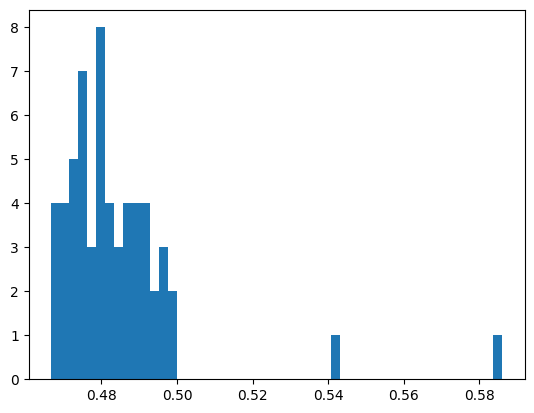

In [18]:
import matplotlib.pyplot as plt 
plt.hist(df_folded["median_rmsd"], bins= 50)

In [6]:
df

,id,sequence,is_wt
0,wild_type,PAGFRQVCKAFMAEPMFNTATQHEYHCCTPTRMYINTPVN,True
1,mutant_1,PKGFRQVCKAFMAEGMFNTATQHECHCYTPTRMYINTPVN,False
2,mutant_2,PAGFREVCKAFMAEPMFNTATQHKHCCTPTRMYINTPVN,False
3,mutant_3,PAGYRQVWKAFMAEPSMFNTATQHEYHCCTPCRMYKNTPVN,False
4,mutant_4,PAGFRQVCKAFMAEPMFNTATQHWYHCCTPTFRQPINTPVN,False
...,...,...,...
496,mutant_496,PAGFRQVCKAFMAEPMFNTATYHEYHCCTPTRMMINTPVN,False
497,mutant_497,PAGFRQHCKAFMATPMFNTATGHEYYHCCTPTRWYINTPVN,False
498,mutant_498,PAGFRQVCKAWMAEPHFNTATQHEYHCCTPNRMYINTPVN,False
499,mutant_499,PAGQFRQVCKAFMAEPVFNWATQHEYHCCTPTRMYINTPVN,False
